In [39]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

import sys
import os
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(parent_dir)

from functions.read_g4bl_data import readTraceData, readDetData
from functions.set_plot_settings import setPlotSettings

setPlotSettings(font=True)

beam gaussian particle=mu+ nEvents=5000 \
beamZ=0.0 beamX=$X beamY=$Y beamXp=$Xp beamYp=$Yp \ 
sigmaX=100.0 sigmaY=100.0 sigmaXp=0.1 sigmaYp=0.1 \ 
meanMomentum=$p sigmaP=100.0 meanT=0.0 sigmaT=0.0

In [65]:
data0 = readDetData('zntuple_grad0_beam.txt')

In [41]:
data1pt25 = readDetData('zntuple_grad1pt25_beam.txt')

In [45]:
numInit = 5000

In [46]:
zvals = np.unique(data1pt25['z']) # same for both datasets
num0 = []
num1pt25 = []
for z in zvals:
    data0_z = data0[data0['z']==z]
    data1pt25_z = data1pt25[data1pt25['z']==z]
    num0.append(len(np.unique(data0_z['EventID']))/numInit)
    num1pt25.append(len(np.unique(data1pt25_z['EventID']))/numInit)
    del data0_z, data1pt25_z

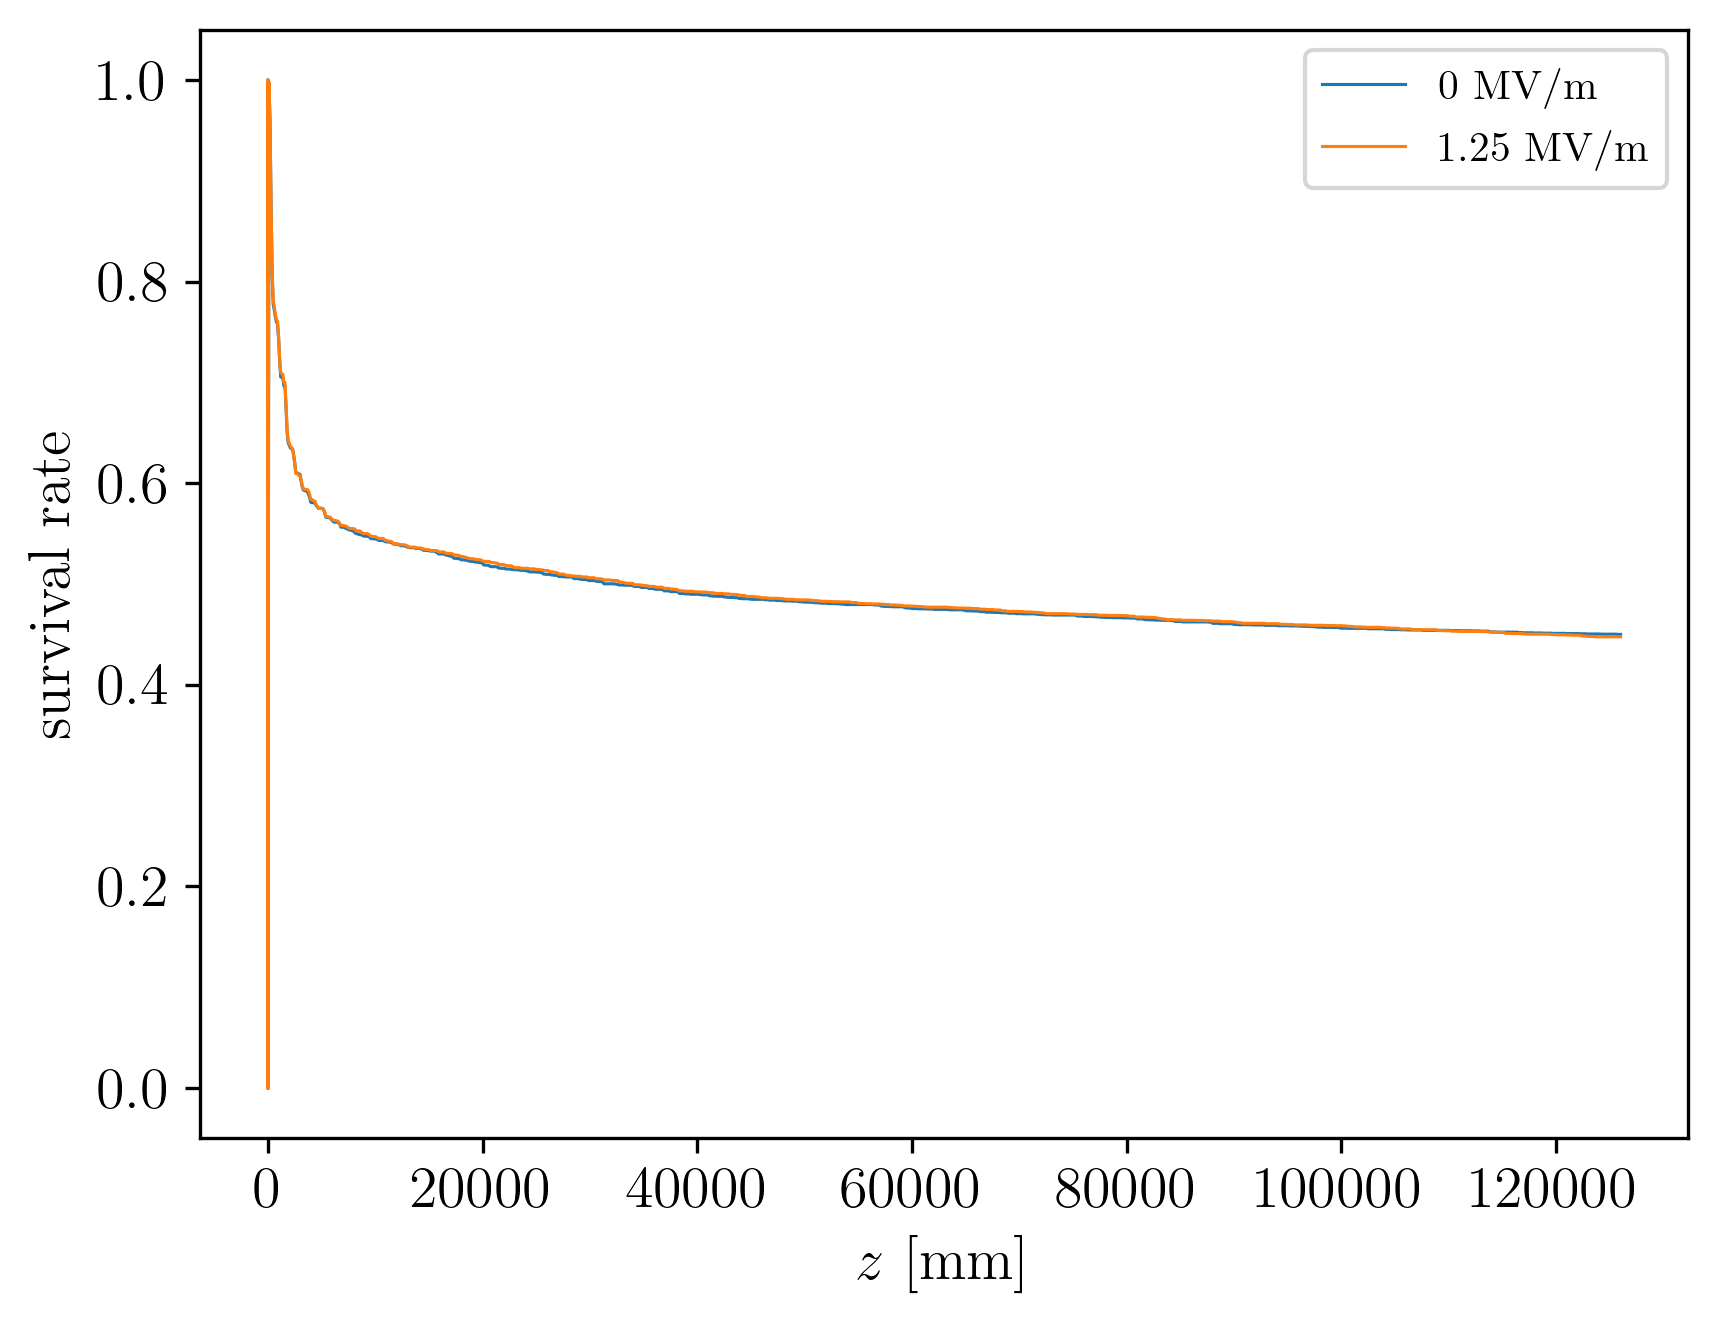

In [58]:
plt.plot(zvals,num0,label='0 MV/m',lw=0.75)
plt.plot(zvals,num1pt25,label='1.25 MV/m',lw=0.75)
plt.xlabel('$z$ [mm]')
plt.ylabel('survival rate')
plt.legend(fontsize=10);

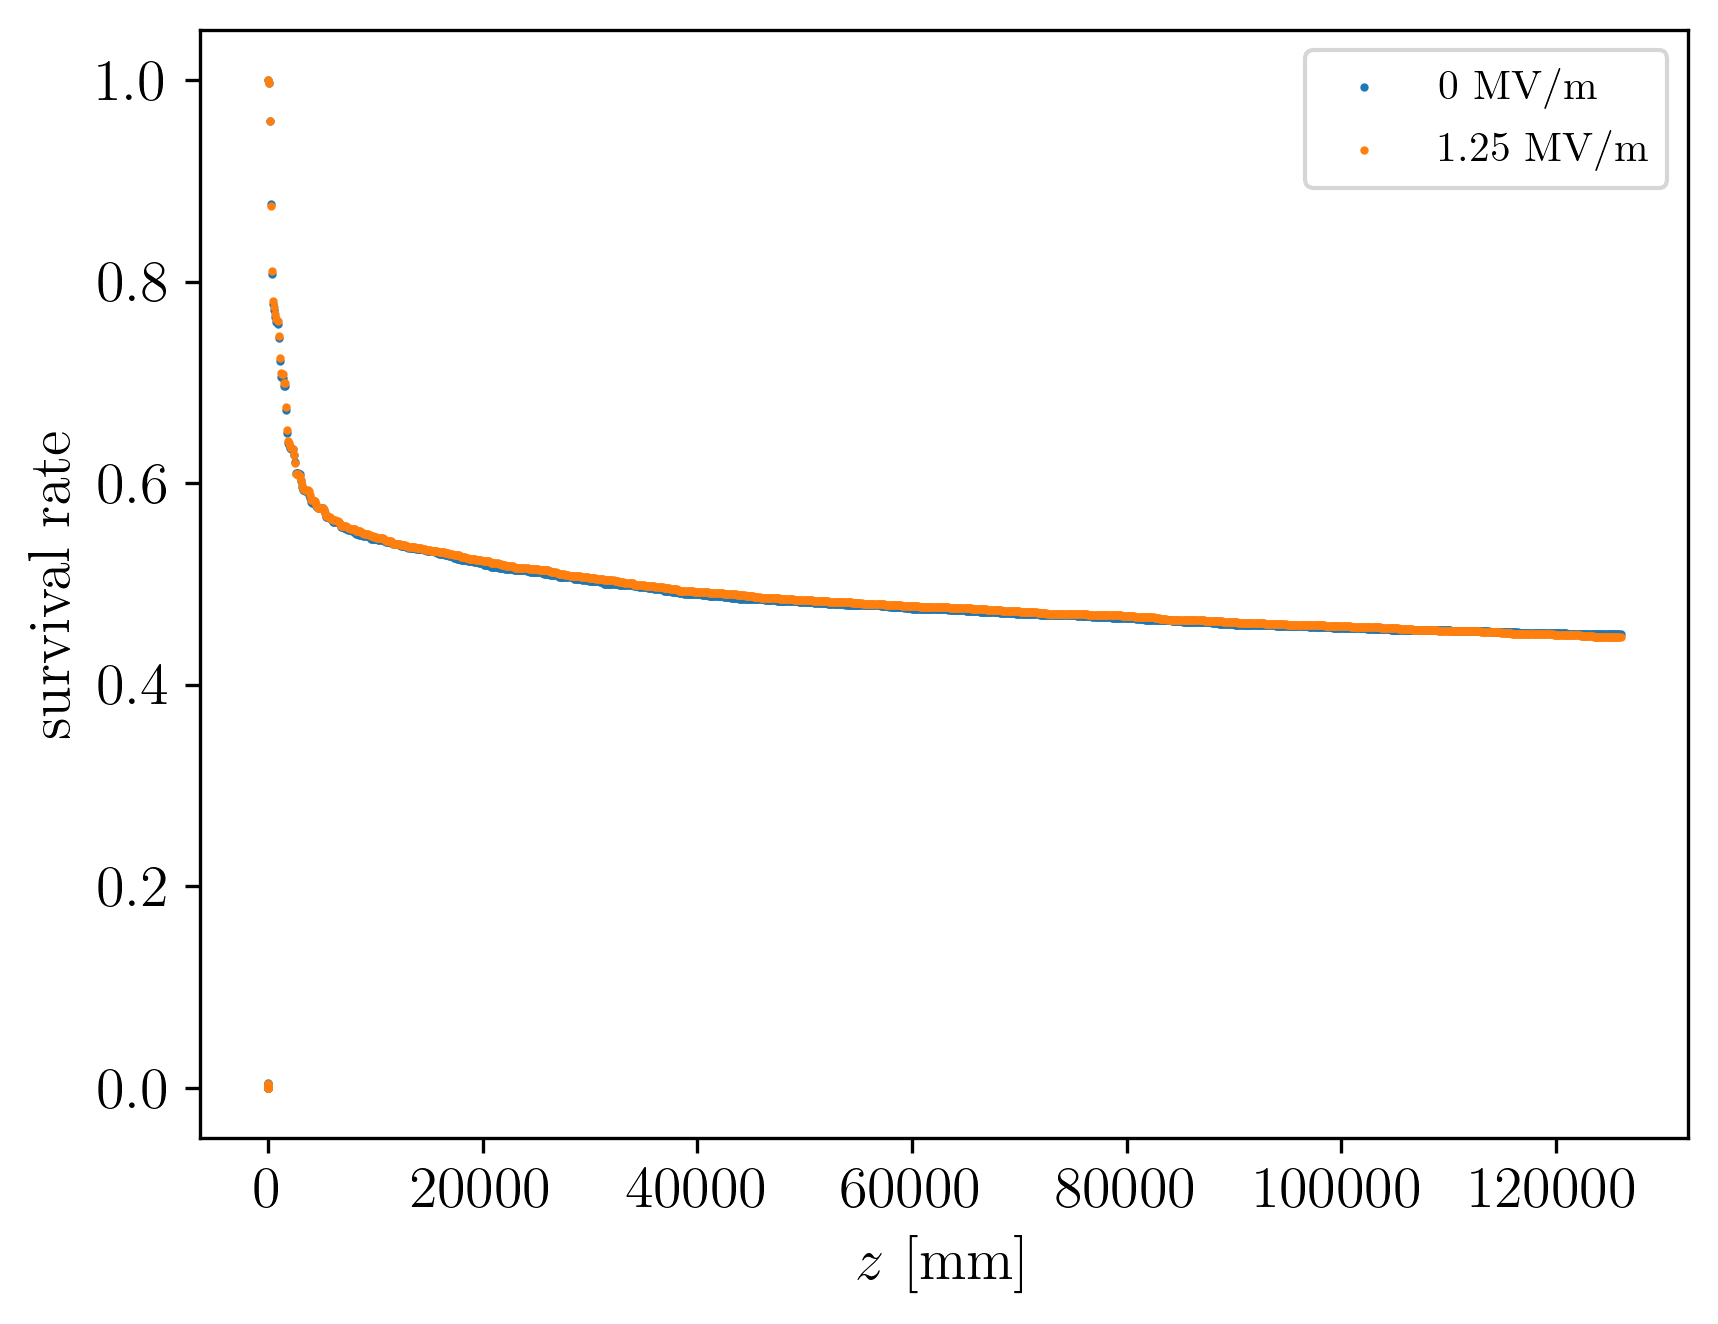

In [59]:
plt.scatter(zvals,num0,label='0 MV/m',s=1)
plt.scatter(zvals,num1pt25,label='1.25 MV/m',s=1)
plt.xlabel('$z$ [mm]')
plt.ylabel('survival rate')
plt.legend(fontsize=10);

### w/ p_total cut

In [67]:
data0 = data0[data0['ptotal']<350]
data0 = data0[data0['ptotal']>150]

data1pt25 = data1pt25[data1pt25['ptotal']<350]
data1pt25 = data1pt25[data1pt25['ptotal']>150]

In [71]:
numInit0 = len(np.unique(data0[data0['z']==0]['EventID']))
numInit1pt25 = len(np.unique(data1pt25[data1pt25['z']==0]['EventID']))

In [72]:
zvals = np.unique(data1pt25['z']) # same for both datasets
num0 = []
num1pt25 = []
for z in zvals:
    data0_z = data0[data0['z']==z]
    data1pt25_z = data1pt25[data1pt25['z']==z]
    num0.append(len(np.unique(data0_z['EventID']))/numInit0)
    num1pt25.append(len(np.unique(data1pt25_z['EventID']))/numInit1pt25)
    del data0_z, data1pt25_z

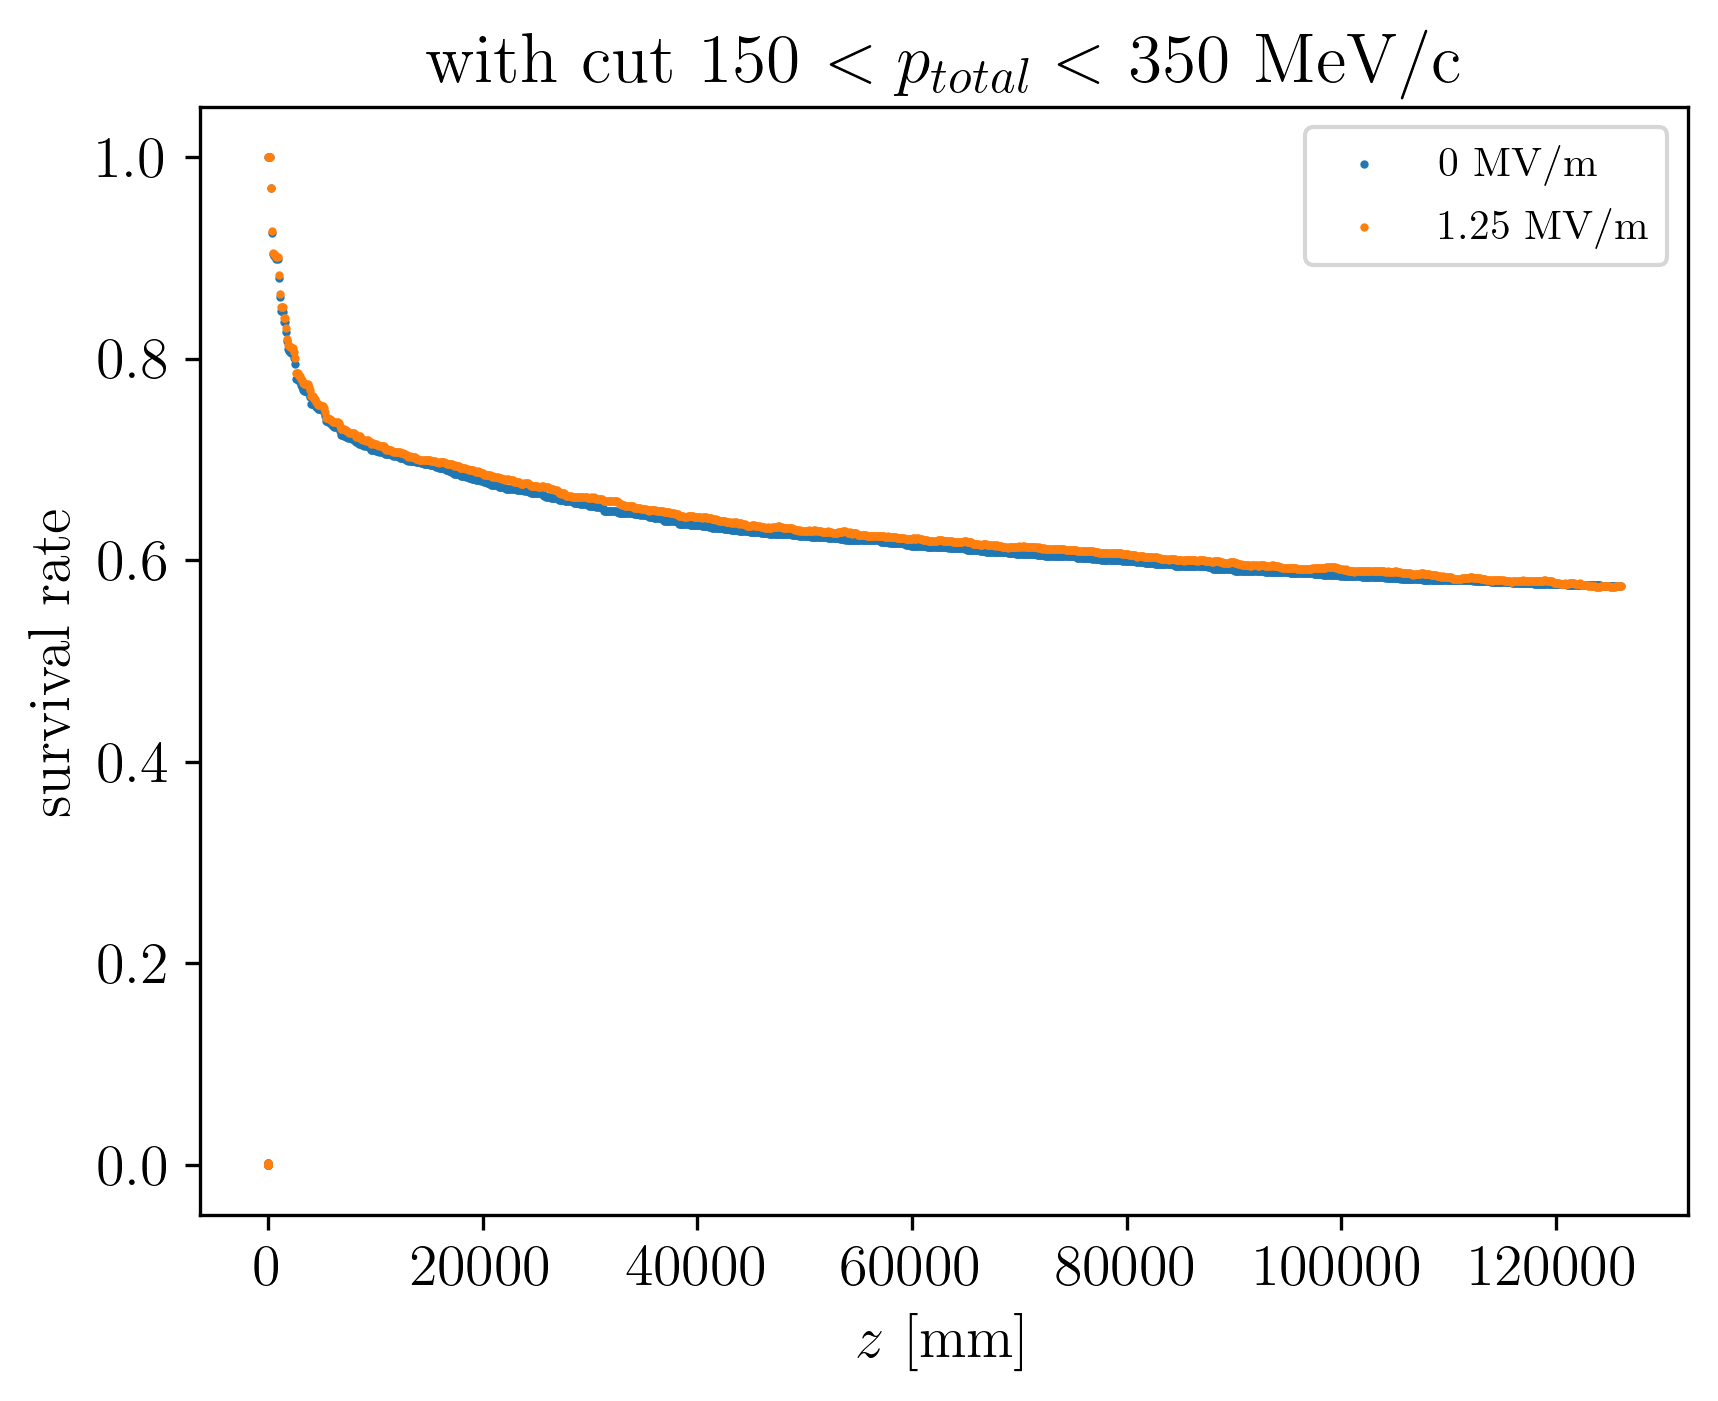

In [88]:
plt.scatter(zvals,num0,label='0 MV/m',s=1)
plt.scatter(zvals,num1pt25,label='1.25 MV/m',s=1)
plt.xlabel('$z$ [mm]')
plt.ylabel('survival rate')
plt.legend(fontsize=10)
plt.title('with cut 150 $< p_{total} <$ 350 MeV/c');

In [79]:
print(num0[-1])
print(num1pt25[-1])

0.5744
0.5744
